# Time Series: ML vs Statistical Models Comparison

This notebook compares Machine Learning and Statistical models for time series forecasting problems.

## Problem Type: Time Series
## Datasets:
- Energy Consumption
- Stock Prices
- Temperature
- Sales Forecasting

## Models:
**ML Models:**
- Multi-layer Perceptron
- Random Forest

**Statistical Models:**
- Generalized Linear Model (statsmodels)


In [1]:
# Import necessary libraries
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import time
import psutil
import os

# ML Models
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

# Statistical Models
import statsmodels.api as sm
from statsmodels.genmod.generalized_linear_model import GLM
from statsmodels.genmod import families

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


## Utility Functions

Functions for time series dataset loading, feature engineering, and model evaluation.


In [2]:
def create_time_series_features(data, n_lags=5):
    """Create features from time series data using lagged values."""
    X, y = [], []
    for i in range(n_lags, len(data)):
        X.append(data[i-n_lags:i])
        y.append(data[i])
    return np.array(X), np.array(y)


def load_dataset(dataset_name):
    """Load and preprocess time series datasets."""
    np.random.seed(42)
    
    if dataset_name == 'energy_consumption':
        # Generate synthetic energy consumption time series
        n_samples = 1000
        t = np.arange(n_samples)
        # Create trend + seasonality + noise
        trend = 100 + 0.05 * t
        seasonal = 20 * np.sin(2 * np.pi * t / 365) + 10 * np.cos(2 * np.pi * t / 52)
        noise = np.random.randn(n_samples) * 5
        data = trend + seasonal + noise
        
    elif dataset_name == 'stock_prices':
        # Generate synthetic stock price time series (random walk with drift)
        n_samples = 1000
        returns = np.random.randn(n_samples) * 0.02 + 0.001  # Small drift
        prices = 100 * np.exp(np.cumsum(returns))
        data = prices
        
    elif dataset_name == 'temperature':
        # Generate synthetic temperature time series
        n_samples = 1000
        t = np.arange(n_samples)
        # Annual cycle with trend
        base_temp = 20 + 0.01 * t / 365  # Slight warming trend
        seasonal = 10 * np.sin(2 * np.pi * t / 365)
        noise = np.random.randn(n_samples) * 2
        data = base_temp + seasonal + noise
        
    elif dataset_name == 'sales_forecasting':
        # Generate synthetic sales forecasting time series
        n_samples = 1000
        t = np.arange(n_samples)
        # Trend + multiple seasonalities
        trend = 50 + 0.1 * t
        weekly = 10 * np.sin(2 * np.pi * t / 7)
        monthly = 5 * np.cos(2 * np.pi * t / 30)
        noise = np.random.randn(n_samples) * 3
        data = trend + weekly + monthly + noise
        
    else:
        raise ValueError(f"Unknown dataset: {dataset_name}")
    
    # Create features from time series
    n_lags = 10
    X, y = create_time_series_features(data, n_lags=n_lags)
    
    return X, y, data


def get_memory_usage():
    """Get current memory usage in MB."""
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / 1024 / 1024


def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, model_type):
    """Evaluate a model and return comprehensive metrics."""
    start_time = time.time()
    memory_before = get_memory_usage()
    
    # Train model
    if model_type == 'statistical':
        # For statsmodels, add constant
        X_train_sm = sm.add_constant(X_train)
        X_test_sm = sm.add_constant(X_test)
        
        model_result = model.fit()
        
        # Predictions
        y_train_pred = model_result.predict(X_train_sm)
        y_test_pred = model_result.predict(X_test_sm)
        
        training_time = time.time() - start_time
        
        pred_start = time.time()
        y_test_pred = model_result.predict(X_test_sm)
        prediction_time = time.time() - pred_start
        
    else:  # ML model
        model.fit(X_train, y_train)
        training_time = time.time() - start_time
        
        pred_start = time.time()
        y_test_pred = model.predict(X_test)
        prediction_time = time.time() - pred_start
        
        y_train_pred = model.predict(X_train)
    
    memory_after = get_memory_usage()
    memory_usage = memory_after - memory_before
    
    # Calculate metrics
    r2 = r2_score(y_test, y_test_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    mae = mean_absolute_error(y_test, y_test_pred)
    
    # Explainability score (0-100)
    if model_type == 'statistical':
        explainability = 90  # GLM
    else:
        if 'Random Forest' in model_name:
            explainability = 50
        else:
            explainability = 30  # MLP
    
    results = {
        'model_name': model_name,
        'model_category': 'ml' if model_type == 'ml' else 'statistical',
        'test_r2': r2,
        'test_rmse': rmse,
        'test_mae': mae,
        'training_time': training_time,
        'prediction_time': prediction_time,
        'memory_usage': memory_usage,
        'explainability_score': explainability,
        'y_test_pred': y_test_pred,
        'y_test': y_test
    }
    
    if model_type == 'statistical':
        results['model_result'] = model_result
    
    return results


print("✅ Utility functions defined!")


✅ Utility functions defined!


## Main Comparison Function


In [3]:
def run_time_series_comparison(dataset_name, test_size=0.2, random_state=42):
    """Run comprehensive comparison for a time series dataset."""
    
    print(f"\n{'='*60}")
    print(f"Dataset: {dataset_name.upper()}")
    print(f"{'='*60}\n")
    
    # Load dataset
    X, y, original_data = load_dataset(dataset_name)
    print(f"Feature shape: {X.shape}")
    print(f"Target shape: {y.shape}")
    print(f"Original time series length: {len(original_data)}")
    
    # Split data (time series split - use last portion as test)
    split_idx = int(len(X) * (1 - test_size))
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]
    
    # Scale features and targets
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)
    y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
    y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).ravel()
    
    all_results = []
    
    # ML Models
    ml_models = {
        'Multi-layer Perceptron': MLPRegressor(hidden_layer_sizes=(100, 50), 
                                               max_iter=500, random_state=random_state),
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=random_state)
    }
    
    print("\n📊 Training ML Models...")
    for name, model in ml_models.items():
        print(f"  - {name}...")
        if name == 'Multi-layer Perceptron':
            # For MLP, use scaled data
            model.fit(X_train_scaled, y_train_scaled)
            y_test_pred_scaled = model.predict(X_test_scaled)
            y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled.reshape(-1, 1)).ravel()
            
            # Calculate metrics with original scale
            start_time = time.time()
            memory_before = get_memory_usage()
            model.fit(X_train_scaled, y_train_scaled)
            training_time = time.time() - start_time
            
            pred_start = time.time()
            y_test_pred = scaler_y.inverse_transform(model.predict(X_test_scaled).reshape(-1, 1)).ravel()
            prediction_time = time.time() - pred_start
            
            memory_after = get_memory_usage()
            memory_usage = memory_after - memory_before
            
            r2 = r2_score(y_test, y_test_pred)
            rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
            mae = mean_absolute_error(y_test, y_test_pred)
            
            results = {
                'model_name': name,
                'model_category': 'ml',
                'test_r2': r2,
                'test_rmse': rmse,
                'test_mae': mae,
                'training_time': training_time,
                'prediction_time': prediction_time,
                'memory_usage': memory_usage,
                'explainability_score': 30,
                'y_test_pred': y_test_pred,
                'y_test': y_test
            }
        else:
            # For Random Forest, use original scale
            results = evaluate_model(model, X_train, X_test, y_train, y_test, name, 'ml')
        all_results.append(results)
    
    # Statistical Models
    print("\n📈 Training Statistical Models...")
    # GLM
    print("  - Generalized Linear Model...")
    X_train_sm = sm.add_constant(X_train)
    glm_model = GLM(y_train, X_train_sm, family=sm.families.Gaussian())
    results = evaluate_model(glm_model, X_train, X_test, y_train, y_test,
                            'Generalized Linear Model (statsmodels)', 'statistical')
    all_results.append(results)
    
    # Create results DataFrame
    results_df = pd.DataFrame([
        {
            'model_name': r['model_name'],
            'model_category': r['model_category'],
            'test_r2': r['test_r2'],
            'test_rmse': r['test_rmse'],
            'test_mae': r['test_mae'],
            'training_time': r['training_time'],
            'prediction_time': r['prediction_time'],
            'memory_usage': r['memory_usage'],
            'explainability_score': r['explainability_score']
        }
        for r in all_results
    ])
    
    return results_df, all_results, X_test, y_test, original_data


print("✅ Comparison function defined!")


✅ Comparison function defined!


## Run Comparisons

Run the comparison for all time series datasets.


In [4]:
# Define datasets
time_series_datasets = ['energy_consumption', 'stock_prices', 'temperature', 'sales_forecasting']

# Store all results
all_dataset_results = {}

for dataset in time_series_datasets:
    try:
        results_df, detailed_results, X_test, y_test, original_data = run_time_series_comparison(dataset)
        all_dataset_results[dataset] = {
            'results_df': results_df,
            'detailed_results': detailed_results,
            'X_test': X_test,
            'y_test': y_test,
            'original_data': original_data
        }
        print(f"\n✅ Completed: {dataset}")
        print(results_df[['model_name', 'model_category', 'test_r2', 'test_rmse', 'training_time']])
        print("\n" + "-"*60 + "\n")
    except Exception as e:
        print(f"❌ Error with {dataset}: {e}")
        import traceback
        traceback.print_exc()
        continue

print("✅ All comparisons completed!")



Dataset: ENERGY_CONSUMPTION

Feature shape: (990, 10)
Target shape: (990,)
Original time series length: 1000

📊 Training ML Models...
  - Multi-layer Perceptron...
  - Random Forest...

📈 Training Statistical Models...
  - Generalized Linear Model...

✅ Completed: energy_consumption
                               model_name model_category   test_r2  test_rmse  \
0                  Multi-layer Perceptron             ml  0.802336   6.239295   
1                           Random Forest             ml  0.802329   6.239398   
2  Generalized Linear Model (statsmodels)    statistical  0.842590   5.567852   

   training_time  
0       0.480231  
1       0.322389  
2       0.001345  

------------------------------------------------------------


Dataset: STOCK_PRICES

Feature shape: (990, 10)
Target shape: (990,)
Original time series length: 1000

📊 Training ML Models...
  - Multi-layer Perceptron...
  - Random Forest...

📈 Training Statistical Models...
  - Generalized Linear Model...

✅ Co

## Visualizations

Create visualizations to compare model performance and time series forecasts.


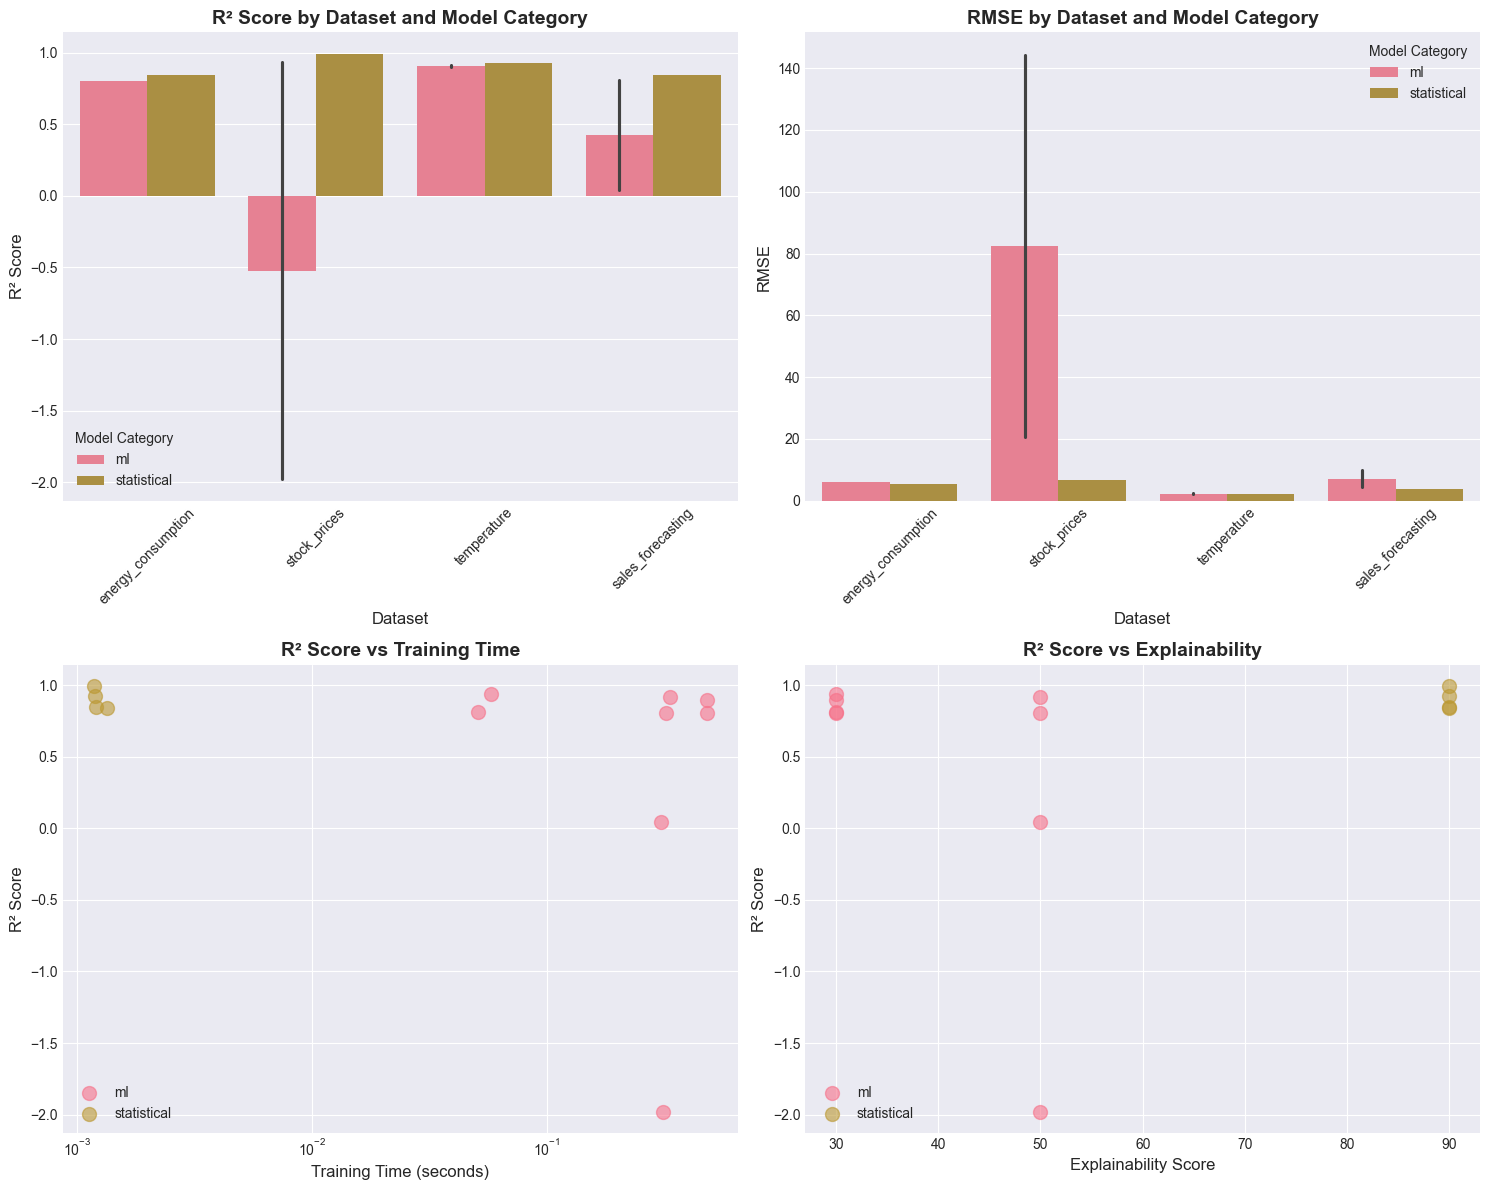

✅ Visualizations created!


In [5]:
# Combine all results for visualization
all_results_combined = []
for dataset_name, data in all_dataset_results.items():
    df = data['results_df'].copy()
    df['dataset'] = dataset_name
    all_results_combined.append(df)

combined_df = pd.concat(all_results_combined, ignore_index=True)

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. R² comparison
ax1 = axes[0, 0]
sns.barplot(data=combined_df, x='dataset', y='test_r2', hue='model_category', ax=ax1)
ax1.set_title('R² Score by Dataset and Model Category', fontsize=14, fontweight='bold')
ax1.set_xlabel('Dataset', fontsize=12)
ax1.set_ylabel('R² Score', fontsize=12)
ax1.legend(title='Model Category')
ax1.tick_params(axis='x', rotation=45)

# 2. RMSE comparison
ax2 = axes[0, 1]
sns.barplot(data=combined_df, x='dataset', y='test_rmse', hue='model_category', ax=ax2)
ax2.set_title('RMSE by Dataset and Model Category', fontsize=14, fontweight='bold')
ax2.set_xlabel('Dataset', fontsize=12)
ax2.set_ylabel('RMSE', fontsize=12)
ax2.legend(title='Model Category')
ax2.tick_params(axis='x', rotation=45)

# 3. R² vs Training Time
ax3 = axes[1, 0]
for category in combined_df['model_category'].unique():
    data = combined_df[combined_df['model_category'] == category]
    ax3.scatter(data['training_time'], data['test_r2'], 
               label=category, alpha=0.6, s=100)
ax3.set_xlabel('Training Time (seconds)', fontsize=12)
ax3.set_ylabel('R² Score', fontsize=12)
ax3.set_title('R² Score vs Training Time', fontsize=14, fontweight='bold')
ax3.legend()
ax3.set_xscale('log')

# 4. Explainability vs R²
ax4 = axes[1, 1]
for category in combined_df['model_category'].unique():
    data = combined_df[combined_df['model_category'] == category]
    ax4.scatter(data['explainability_score'], data['test_r2'], 
               label=category, alpha=0.6, s=100)
ax4.set_xlabel('Explainability Score', fontsize=12)
ax4.set_ylabel('R² Score', fontsize=12)
ax4.set_title('R² Score vs Explainability', fontsize=14, fontweight='bold')
ax4.legend()

plt.tight_layout()
plt.show()

print("✅ Visualizations created!")


## Time Series Forecast Visualization

Visualize actual vs predicted values for a sample dataset.


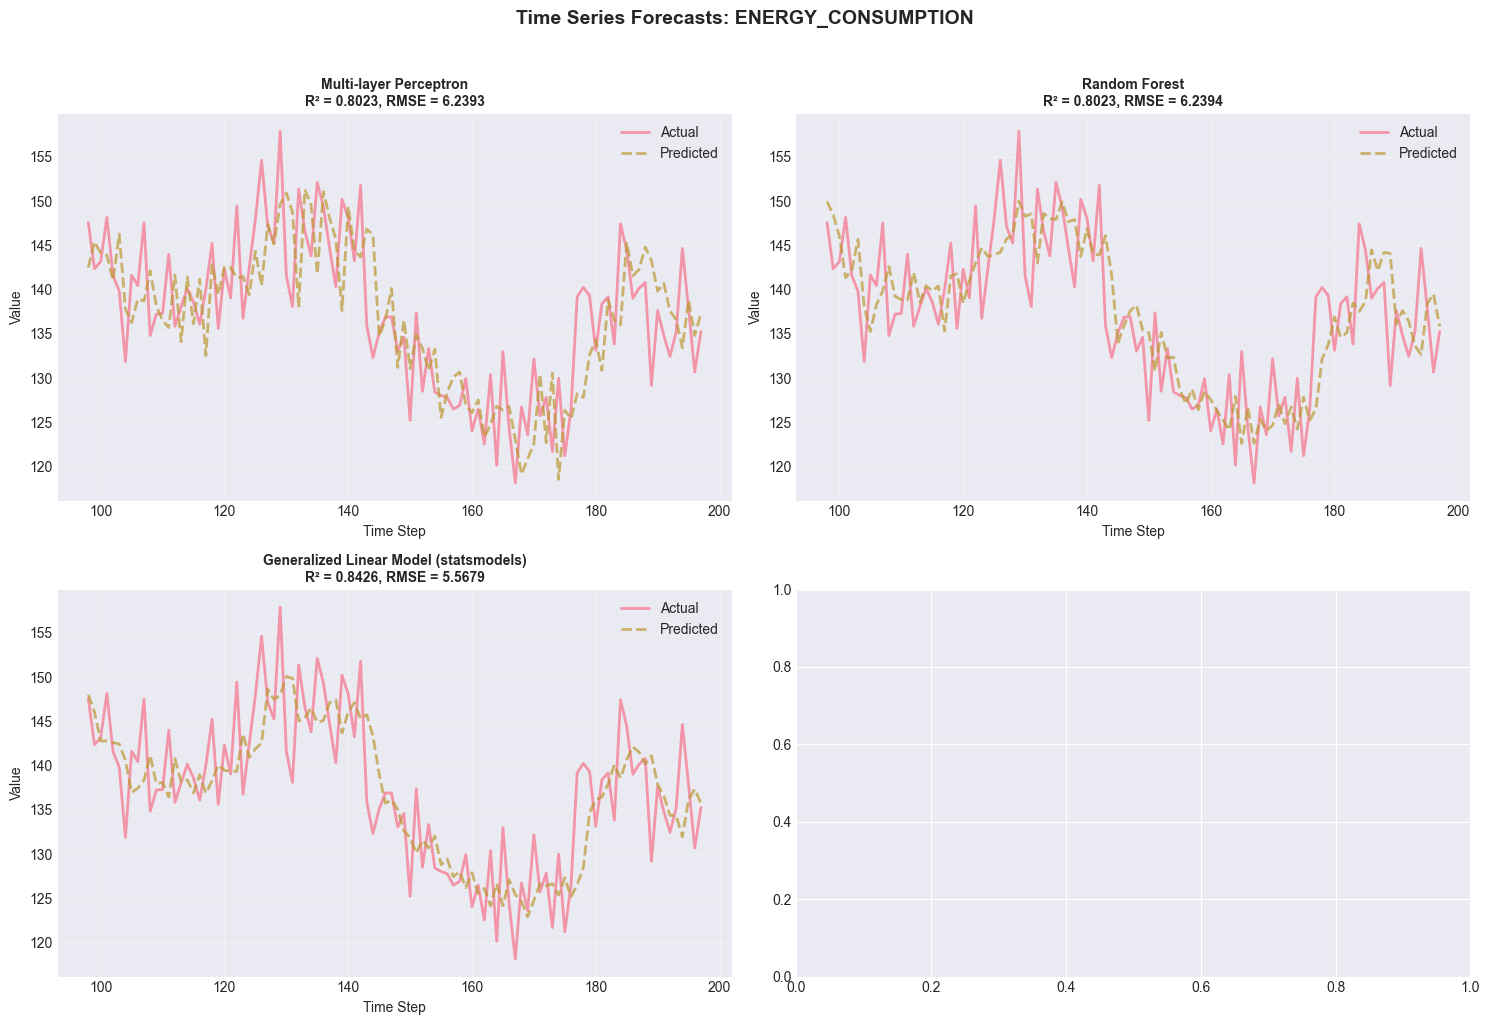

✅ Forecast visualizations created!


In [6]:
# Plot forecasts for the first dataset
if len(all_dataset_results) > 0:
    first_dataset = list(all_dataset_results.keys())[0]
    data = all_dataset_results[first_dataset]
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, result in enumerate(data['detailed_results']):
        if idx < 4:
            ax = axes[idx]
            y_test = result['y_test']
            y_pred = result['y_test_pred']
            
            # Plot last 100 points for clarity
            n_points = min(100, len(y_test))
            x_range = np.arange(len(y_test) - n_points, len(y_test))
            
            ax.plot(x_range, y_test[-n_points:], label='Actual', linewidth=2, alpha=0.7)
            ax.plot(x_range, y_pred[-n_points:], label='Predicted', linewidth=2, alpha=0.7, linestyle='--')
            ax.set_title(f"{result['model_name']}\nR² = {result['test_r2']:.4f}, RMSE = {result['test_rmse']:.4f}", 
                        fontsize=10, fontweight='bold')
            ax.set_xlabel('Time Step', fontsize=10)
            ax.set_ylabel('Value', fontsize=10)
            ax.legend()
            ax.grid(True, alpha=0.3)
    
    plt.suptitle(f'Time Series Forecasts: {first_dataset.upper()}', 
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

print("✅ Forecast visualizations created!")


## Summary Statistics

Display summary statistics across all datasets.


In [7]:
# Summary statistics
print("="*80)
print("TIME SERIES MODELS COMPARISON SUMMARY")
print("="*80)

print("\n📊 Overall Performance by Model Category:")
summary = combined_df.groupby('model_category').agg({
    'test_r2': ['mean', 'std', 'min', 'max'],
    'test_rmse': ['mean', 'std'],
    'training_time': ['mean', 'std'],
    'explainability_score': 'mean'
}).round(4)
print(summary)

print("\n🏆 Best Model per Dataset:")
for dataset in time_series_datasets:
    if dataset in all_dataset_results:
        df = all_dataset_results[dataset]['results_df']
        best_model = df.loc[df['test_r2'].idxmax()]
        print(f"\n{dataset.upper()}:")
        print(f"  Model: {best_model['model_name']}")
        print(f"  Category: {best_model['model_category']}")
        print(f"  R²: {best_model['test_r2']:.4f}")
        print(f"  RMSE: {best_model['test_rmse']:.4f}")
        print(f"  Training Time: {best_model['training_time']:.4f}s")

print("\n⚡ Fastest Model:")
fastest = combined_df.loc[combined_df['training_time'].idxmin()]
print(f"  Model: {fastest['model_name']}")
print(f"  Dataset: {fastest['dataset']}")
print(f"  Training Time: {fastest['training_time']:.4f}s")

print("\n🧠 Most Interpretable Model:")
most_interp = combined_df.loc[combined_df['explainability_score'].idxmax()]
print(f"  Model: {most_interp['model_name']}")
print(f"  Dataset: {most_interp['dataset']}")
print(f"  Explainability Score: {most_interp['explainability_score']}/100")

print("\n" + "="*80)


TIME SERIES MODELS COMPARISON SUMMARY

📊 Overall Performance by Model Category:
               test_r2                         test_rmse           \
                  mean     std     min     max      mean      std   
model_category                                                      
ml              0.4039  1.0067 -1.9810  0.9383   24.5588  48.7758   
statistical     0.9016  0.0727  0.8426  0.9938    4.5502   1.9661   

               training_time         explainability_score  
                        mean     std                 mean  
model_category                                             
ml                    0.2930  0.1635                 40.0  
statistical           0.0012  0.0001                 90.0  

🏆 Best Model per Dataset:

ENERGY_CONSUMPTION:
  Model: Generalized Linear Model (statsmodels)
  Category: statistical
  R²: 0.8426
  RMSE: 5.5679
  Training Time: 0.0013s

STOCK_PRICES:
  Model: Generalized Linear Model (statsmodels)
  Category: statistical
  R²: 0.9938
 